In [5]:
import numpy as np
rng = np.random.default_rng()

# Mean estimation

Here we are estimating a mean. Let us start from defining the RV whose expected value we want to estimate.

- $\omega_t \sim P$
- $\mu = E_P[\omega_t]$ 

We are going to run the experiment for $T$ steps, and plot three different estimates:

1. The *empirical* mean $\mu_t = 1/t \sum_{i=1}^t \omega_i$.
This can be calculated recursively as 
$\mu_t = \mu_{t-1} \frac{t-1}{t} + \omega_t \frac{1}{t} = \mu_{t-1} + (\omega_t - \mu_{t-1}) \frac{1}{t}$.

2. The *oracle* mean, the parameter updated with the exact gradient (which assumes you know $\mu$, and so is not implementable in practice).

3. The *gradient* mean, the parameter updated with the noisy gradient:
$\mu_t = \mu_{t-1} + \alpha_t (\omega_t - \mu_{t-1})$.

Let us check all these in practice:


In [21]:
# First, we try with fixed alpha:
mu = 0.5
T = 100
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 0.1
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        

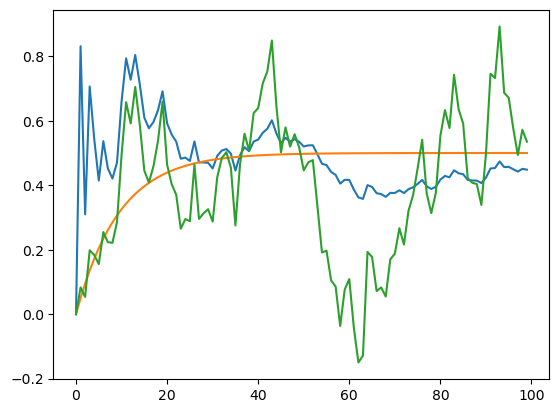

In [25]:
import matplotlib.pyplot as plt
plt.plot(empirical_mean)
plt.plot(oracle_mean)
plt.plot(gradient_mean)

# Alpha fixed 

When $\alpha$ is fixed, the gradient method moves up and down around the mean value with the same speed, more or less. So, it does not converge.

However the oracle method, which has knowledge that is impossible to have, converges. Why is that?


In [28]:
# Now, we try with alpha=1/t:
mu = 0.5
T = 100
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 1/t
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        

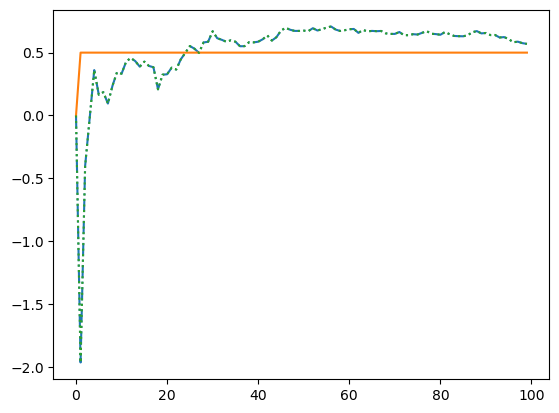

In [33]:
plt.plot(empirical_mean, '-.')
plt.plot(oracle_mean)
plt.plot(gradient_mean, ':')

# Special case $\alpha_t = 1/t$

- Note that the empirical mean udpate is the same as the noisy gradient update if $\alpha_t = 1/t$.
- Why is the oracle update immediately equal to $\mu$?


In [37]:
# Now, we try with alpha=2/(2+t):
mu = 0.5
T = 100
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 1/(10+t)
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        

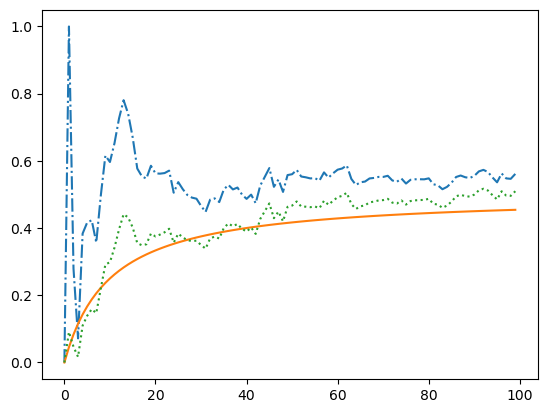

In [38]:
plt.plot(empirical_mean, '-.')
plt.plot(oracle_mean)
plt.plot(gradient_mean, ':')

# Alpha $1/(10 + t)$.

In the above plot, $\alpha$ is still decreasing with rate O(1/t), but it has an overall lower value. Hence, everything converges more slowly, but it is still guaranteed to converge.


In [45]:
# Now, we try with alpha=1/(sqrt(t)):
mu = 0.5
T = 10000
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 1/np.sqrt(t)
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        
        

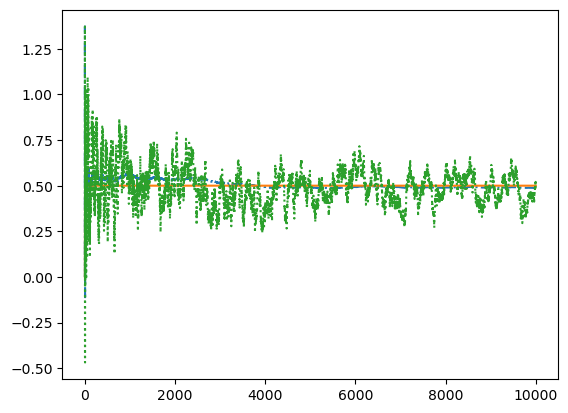

In [46]:
plt.plot(empirical_mean, '-.')
plt.plot(oracle_mean)
plt.plot(gradient_mean, ':')

# Alpha $1/sqrt(t)$.

In the above plot, $\alpha$ is decreasing with rate O(1/log(t)). This is too large and convergence is not guaranteed. Indeed, even when T=1000, we see that we are jumping around the expected value.


In [47]:
# Now, we try with alpha=1/t^2
mu = 0.5
T = 1000
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 1/(t**2)
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        
        

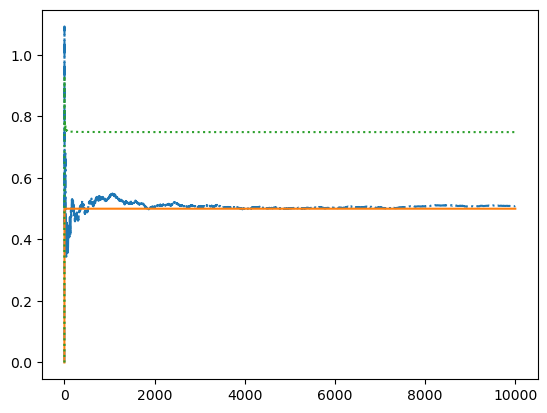

In [48]:
plt.plot(empirical_mean, '-.')
plt.plot(oracle_mean)
plt.plot(gradient_mean, ':')

#  $\alpha = t^{-2}$.

In the above plot, $\alpha$ is decreasing with rate $O(1/t^2)$. This is too small and convergence is not guaranteed. Indeed, the gradient estimate gets stuck at 